# Broadway Network Analysis

## Objectives

This notebook explores the structure of the Broadway network created in Notebook 01.

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/broadway_cast.csv")

G = nx.Graph()

for _, row in df.iterrows():
    G.add_edge(row["person"], row["show"])

In [ ]:
print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")
print(nx.density(G))
print(nx.number_connected_components(G))

In [3]:
degrees = dict(G.degree())

degrees

{'Lin-Manuel Miranda': 1,
 'Hamilton': 3,
 'Leslie Odom Jr.': 1,
 'Phillipa Soo': 1,
 'Idina Menzel': 2,
 'Wicked': 2,
 'Kristin Chenoweth': 1,
 'Rent': 3,
 'Anthony Rapp': 1,
 'Adam Pascal': 1,
 'Angela Lansbury': 1,
 'Sweeney Todd': 3,
 'Len Cariou': 1,
 'Stephen Sondheim': 2,
 'Into the Woods': 2,
 'Bernadette Peters': 1}

In [ ]:
sorted(
    degrees.items(),
    key=lambda x: x[1],
    reverse=True
)

In [6]:
shows = set(df["show"])
node_colors = []

for node in G.nodes():
    if node in shows:
        node_colors.append("lightblue")
    else:
        node_colors.append("lightgreen")

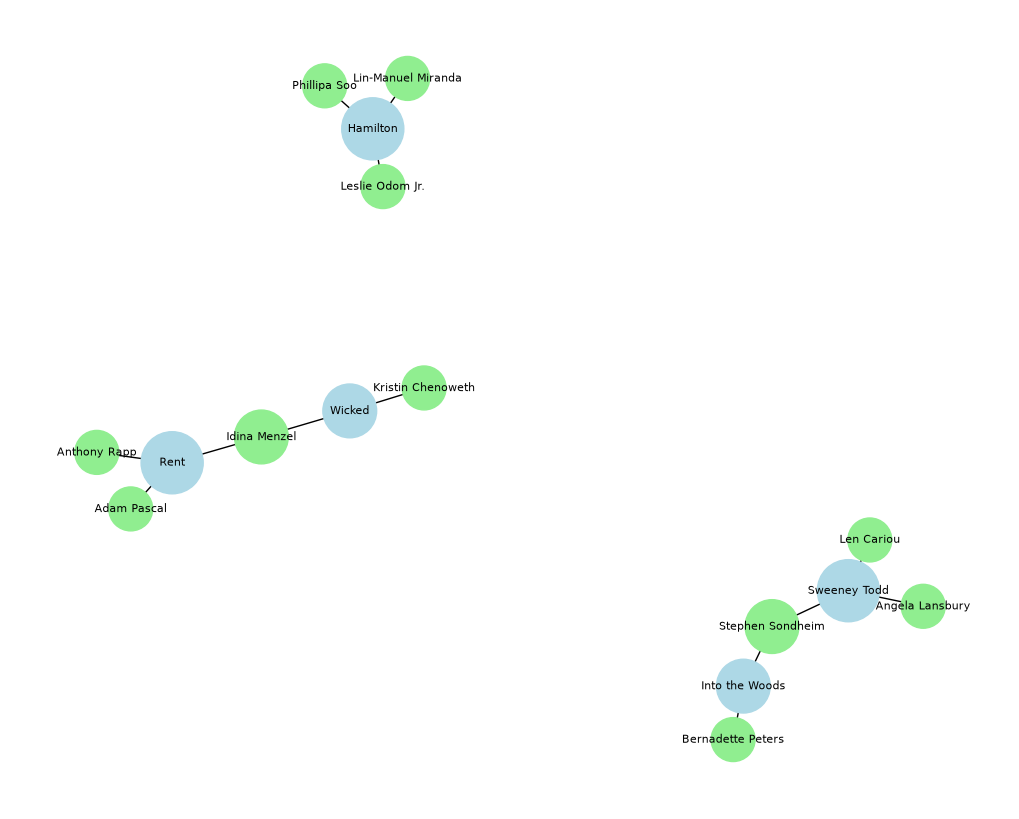

In [11]:
plt.figure(figsize=(10,8))

pos = nx.spring_layout(G, seed=42)

node_sizes = [
    500 + 500*G.degree(node)
    for node in G.nodes()
]

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=node_colors,
    node_size=node_sizes,
    font_size=8
)

plt.show()

## Observations

The manually created Broadway dataset forms three disconnected components.

The Hamilton cast is isolated.

Rent and Wicked are connected through Idina Menzel.

Sweeney Todd and Into the Woods are connected through Stephen Sondheim.

This demonstrates that performers and creators naturally act as bridges between productions, supporting the use of graph-based modelling.